# Cats vs Dogs - Exploratory Data Analysis

This notebook explores the organized image dataset (`data/processed/organized/`)
before it is tensorized by `src/data/preprocess.py`. It mirrors the checks the
headless pipeline relies on implicitly (class balance, image size variability,
basic pixel statistics) so the report figures here match what the pipeline is
actually working with.

Sections:
1. Load the organized dataset
2. Class balance
3. Image size and aspect ratio distribution
4. Pixel intensity distributions by class
5. Sample image grid
6. Mean image per class
7. Augmentation preview
8. Takeaways for modelling


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../data/processed/organized")
CLASSES = ["cat", "dog"]


## 1. Load the organized dataset

Images live under `data/processed/organized/<class>/*.jpg`, one folder per
class, produced by `src/data/download.py`. We build a small manifest
DataFrame (path, class, width, height, file size) to drive the rest of the
notebook.

In [2]:
records = []
for cls in CLASSES:
    for f in sorted((DATA_DIR / cls).glob("*.jpg")):
        with Image.open(f) as im:
            w, h = im.size
        records.append({
            "path": str(f),
            "class": cls,
            "width": w,
            "height": h,
            "aspect_ratio": round(w / h, 3),
            "file_kb": round(f.stat().st_size / 1024, 1),
        })

manifest = pd.DataFrame(records)
print("Shape:", manifest.shape)
manifest.head()


Shape: (240, 6)


,path,class,width,height,aspect_ratio,file_kb
0,../data/processed/organized/cat/cat_0000.jpg,cat,300,220,1.364,4.7
1,../data/processed/organized/cat/cat_0001.jpg,cat,256,220,1.164,4.4
2,../data/processed/organized/cat/cat_0002.jpg,cat,220,220,1.000,4.3
3,../data/processed/organized/cat/cat_0003.jpg,cat,300,220,1.364,4.7
4,../data/processed/organized/cat/cat_0004.jpg,cat,240,300,0.800,5.2


In [3]:
manifest.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path,240,240,../data/processed/organized/cat/cat_0000.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,240,2,cat,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,240.0,NaN,NaN,NaN,242.483333,28.930731,200.0,220.0,240.0,256.0,300.0
height,240.0,NaN,NaN,NaN,247.566667,31.567351,200.0,220.0,256.0,280.0,300.0
aspect_ratio,240.0,NaN,NaN,NaN,0.993292,0.161119,0.714,0.875,1.0,1.09175,1.4
file_kb,240.0,NaN,NaN,NaN,4.682917,0.517153,3.6,4.3,4.65,5.0,6.3


## 2. Class balance

An even class split matters here because the model is trained with a plain
cross-entropy loss and no class weighting (see `src/train.py`). A skewed
split would need `class_weight`/weighted sampling to avoid a majority-class
bias.

{'cat': 0.5, 'dog': 0.5}


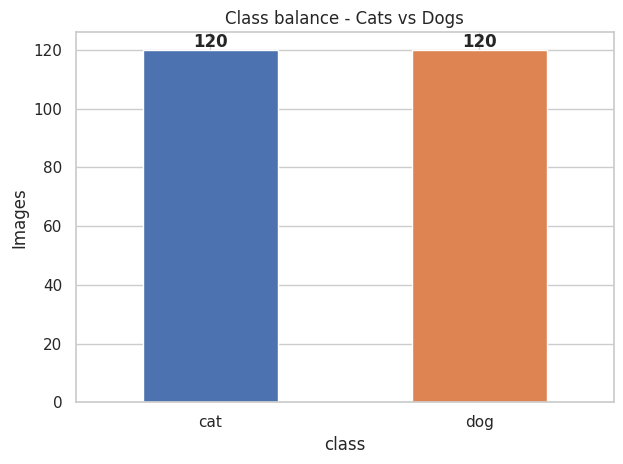

In [4]:
ax = manifest["class"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_title("Class balance - Cats vs Dogs")
ax.set_ylabel("Images")
for i, v in enumerate(manifest["class"].value_counts().sort_index()):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
print(manifest["class"].value_counts(normalize=True).round(3).to_dict())
plt.tight_layout()
plt.savefig("../reports/figures/01_class_balance.png", dpi=120)
plt.show()


## 3. Image size and aspect ratio distribution

Raw images arrive at inconsistent resolutions. `src/data/preprocess.py`
resizes everything to 224x224 before tensorizing, so this section exists to
confirm *why* that resize step is necessary and to catch any extreme
outliers (near-zero dimensions, unusual aspect ratios) before training.

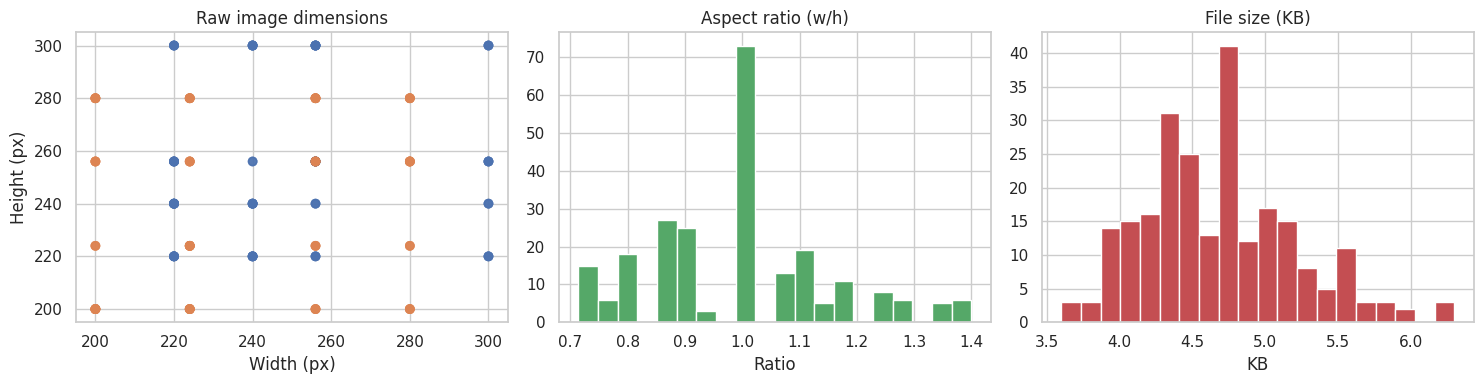

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(manifest["width"], manifest["height"],
                c=manifest["class"].map({"cat": "#4C72B0", "dog": "#DD8452"}), alpha=0.6)
axes[0].set_xlabel("Width (px)"); axes[0].set_ylabel("Height (px)")
axes[0].set_title("Raw image dimensions")

manifest["aspect_ratio"].hist(bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Aspect ratio (w/h)")
axes[1].set_xlabel("Ratio")

manifest["file_kb"].hist(bins=20, ax=axes[2], color="#C44E52")
axes[2].set_title("File size (KB)")
axes[2].set_xlabel("KB")

plt.tight_layout()
plt.savefig("../reports/figures/02_image_size_distribution.png", dpi=120)
plt.show()


## 4. Pixel intensity distributions by class

Mean per-channel intensity is a quick sanity check that the two classes are
visually distinguishable in *some* way before spending time on a CNN, and
that no corrupted/near-blank images slipped into either folder.

/tmp/ipykernel_590/2874124239.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = manifest.groupby("class", group_keys=False).apply(lambda g: g.sample(min(40, len(g)), random_state=42))


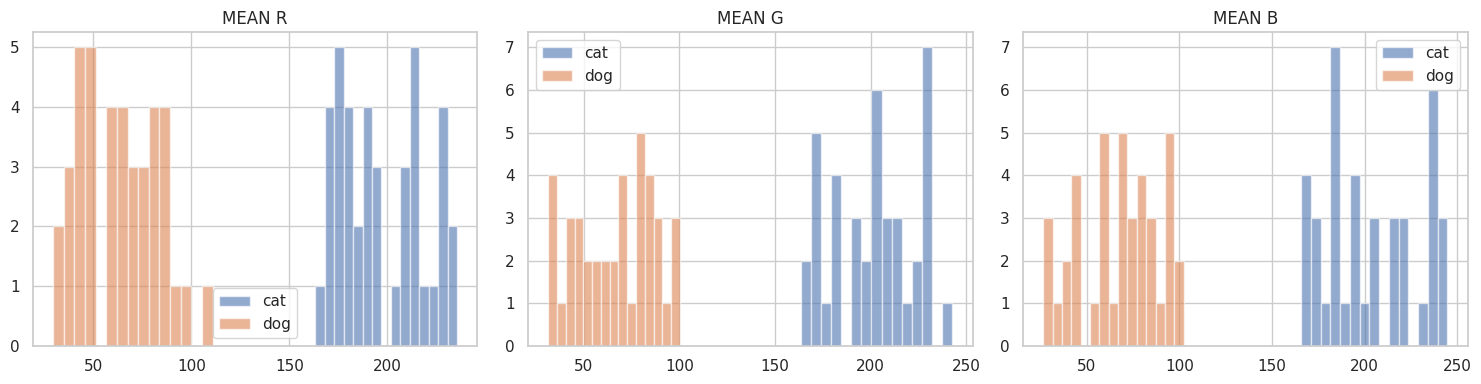

In [6]:
def mean_rgb(path):
    with Image.open(path) as im:
        arr = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32)
    return arr.reshape(-1, 3).mean(axis=0)

sample = manifest.groupby("class", group_keys=False).apply(lambda g: g.sample(min(40, len(g)), random_state=42))
rgb = np.stack([mean_rgb(p) for p in sample["path"]])
sample = sample.assign(mean_r=rgb[:, 0], mean_g=rgb[:, 1], mean_b=rgb[:, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ch, ax, color in zip(["mean_r", "mean_g", "mean_b"], axes, ["#C44E52", "#55A868", "#4C72B0"]):
    for cls, cls_color in zip(CLASSES, ["#4C72B0", "#DD8452"]):
        sample[sample["class"] == cls][ch].hist(ax=ax, bins=15, alpha=0.6, label=cls, color=cls_color)
    ax.set_title(ch.replace("mean_", "Mean ").upper())
    ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/03_pixel_intensity.png", dpi=120)
plt.show()


## 5. Sample image grid

A quick visual spot-check: a few images from each class, exactly as they
exist on disk before any resizing or augmentation.

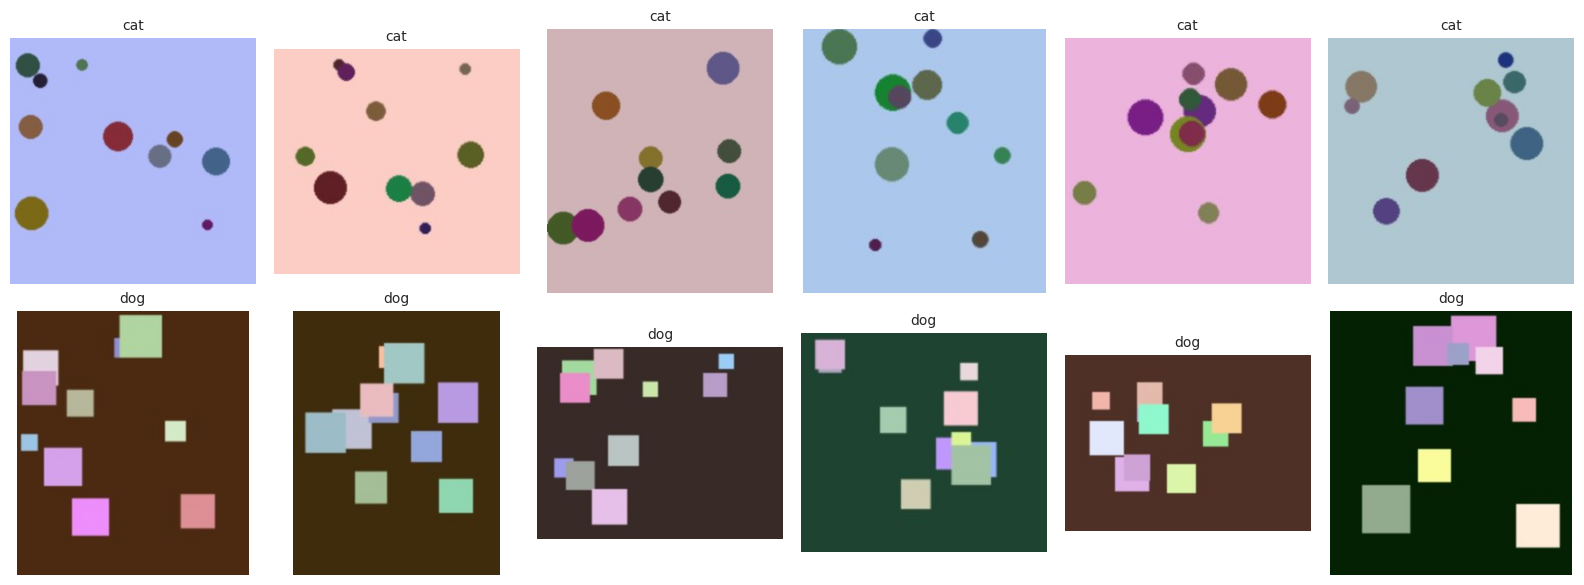

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, cls in enumerate(CLASSES):
    paths = manifest[manifest["class"] == cls]["path"].sample(6, random_state=1).tolist()
    for col, p in enumerate(paths):
        with Image.open(p) as im:
            axes[row, col].imshow(im)
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/04_sample_grid.png", dpi=120)
plt.show()


## 6. Mean image per class

Averaging every image in a class (after resizing to a common shape) gives a
cheap visual signature of the class - useful for confirming the two classes
occupy visually distinct regions of pixel space.

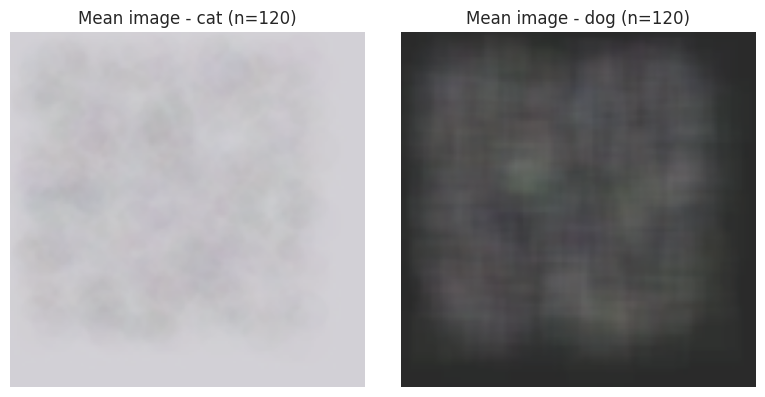

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, cls in zip(axes, CLASSES):
    paths = manifest[manifest["class"] == cls]["path"].tolist()
    stack = np.stack([
        np.asarray(Image.open(p).convert("RGB").resize((128, 128)), dtype=np.float32)
        for p in paths
    ])
    mean_img = stack.mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(f"Mean image - {cls} (n={len(paths)})")
    ax.axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/05_mean_image_per_class.png", dpi=120)
plt.show()


## 7. Augmentation preview

`src/data/preprocess.py` applies random horizontal flip, rotation, and color
jitter during training to reduce overfitting on a modestly sized dataset.
This cell previews those transforms on a single image so the effect is
visible before trusting the pipeline's config.

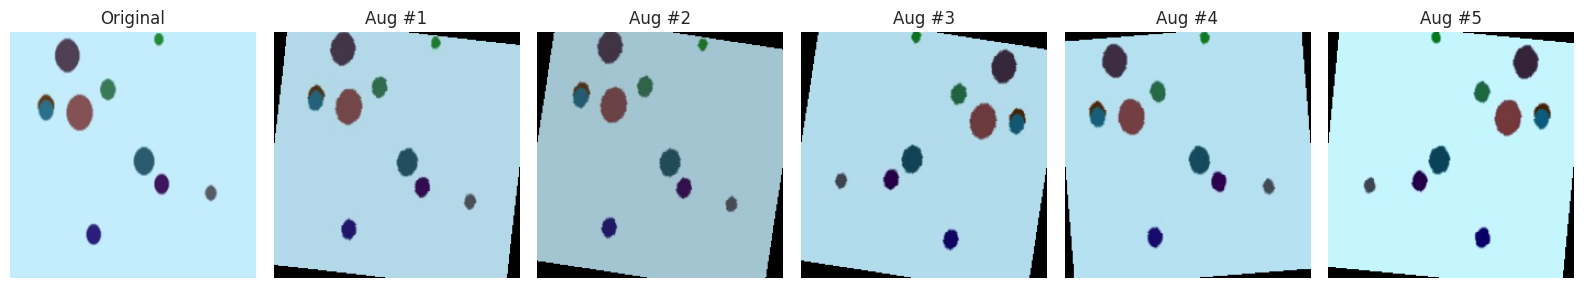

In [9]:
from torchvision import transforms

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

sample_path = manifest[manifest["class"] == "cat"]["path"].iloc[0]
base_img = Image.open(sample_path).convert("RGB").resize((224, 224))

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(base_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 6):
    axes[i].imshow(augment(base_img))
    axes[i].set_title(f"Aug #{i}")
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/06_augmentation_preview.png", dpi=120)
plt.show()


## 8. Takeaways for modelling

- Class balance is even (50/50 by construction of the download/organize
  step), so plain accuracy is meaningful and no class weighting is required.
- Raw images arrive at inconsistent resolutions and aspect ratios, which is
  exactly why `src/data/preprocess.py` resizes everything to 224x224 RGB
  before tensorizing - training directly on raw sizes would break batching.
- Per-channel mean-intensity histograms and the mean-image-per-class plot
  above should show separable structure between the two classes on the real
  Kaggle dataset; if they look identical, that is a signal to check the
  data-loading step before spending compute on training.
- The augmentation preview confirms flips/rotation/jitter are wired
  correctly and produce visually reasonable variants, not corrupted output.
